# 📊 GujEstateAI — Phase 1: Exploratory Data Analysis
**Notebook:** `notebooks/01_eda.ipynb`  
**Dataset:** `data/raw/ProjectInfo_Gujarat.csv`  
**Reference:** Architecture Guide — Step 1.2 & Step 1.3

---
### Plots Covered (Step 1.2)
1. Distribution of `projectType` — bar chart  
2. Projects per year (2010–2023) — line chart  
3. Top 10 districts by project count — horizontal bar  
4. Distribution of `totalEstimatedCost` — histogram with log scale  
5. Distribution of project duration (months) — histogram  
6. Booking rate distribution — histogram  
7. `avgCostPerSqFt` by `projectType` — boxplot  
8. Correlation heatmap — all numeric columns  

### Key Findings (Step 1.3)
- Derived columns: `duration_months`, `booking_rate`, `margin`  
- Summary stats printed  
- All plots saved to `reports/`

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'    : 130,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

# ── Directories ───────────────────────────────────────────────────────────────
os.makedirs('../reports', exist_ok=True)

def save_fig(filename):
    path = f'../reports/{filename}.png'
    plt.savefig(path, bbox_inches='tight', dpi=130)
    print(f'  ✅  Saved → {path}')

print('Setup complete ✔')

Setup complete ✔


## Step 1.1 — Load and Inspect

In [2]:
df = pd.read_csv('../data/raw/ProjectInfo_Gujarat.csv')

print(df.shape)                                        # (14507, 44)
print(df.dtypes)
print(df.isnull().sum() / len(df) * 100)              # null percentages
print(df.describe())

(14507, 44)
projectRegId                      int64
projectName                      object
promoterName                     object
projectType                      object
promoterType                     object
architect_name                   object
eng_name                         object
projectAddress                   object
projectAddress2                  object
pinCode                         float64
tPNo                             object
underRedevelopment               object
distName                         object
tpo_code                         object
startDate                        object
location_coordinates             object
startProjectYear                float64
startProjectMonth               float64
completionDate                   object
EndProjectYear                  float64
EndProjectMonth                 float64
totalProjects                     int64
totalUnits                      float64
bookedUnits                     float64
noOfInventory               

## Step 1.2 — Key EDA Plots
### Plot 1 — Distribution of `projectType` (Bar Chart)

  ✅  Saved → ../reports/plot1_projectType_distribution.png


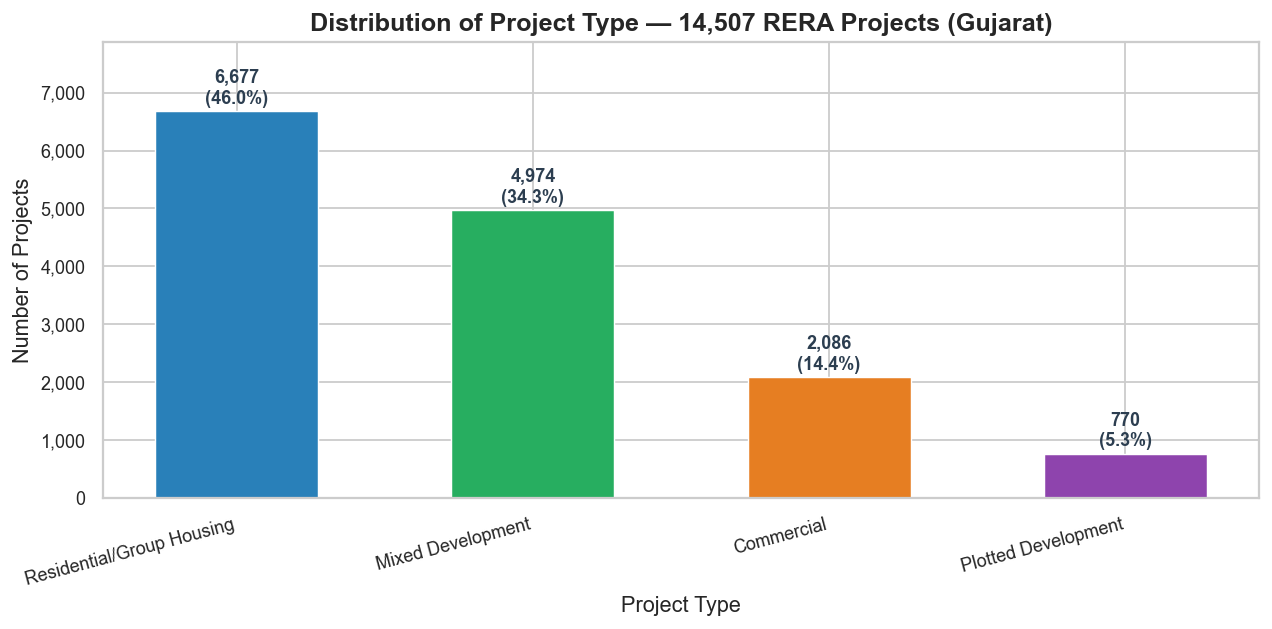

In [3]:
pt_counts = df['projectType'].value_counts()

colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pt_counts.index, pt_counts.values,
              color=colors, edgecolor='white', linewidth=0.8, width=0.55)

# Value labels on top of bars
for bar, val in zip(bars, pt_counts.values):
    pct = val / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50'
    )

ax.set_title('Distribution of Project Type — 14,507 RERA Projects (Gujarat)', fontweight='bold')
ax.set_xlabel('Project Type')
ax.set_ylabel('Number of Projects')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, pt_counts.max() * 1.18)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
save_fig('plot1_projectType_distribution')
plt.show()

### Plot 2 — Projects Per Year 2010–2023 (Line Chart)

  ✅  Saved → ../reports/plot2_projects_per_year.png


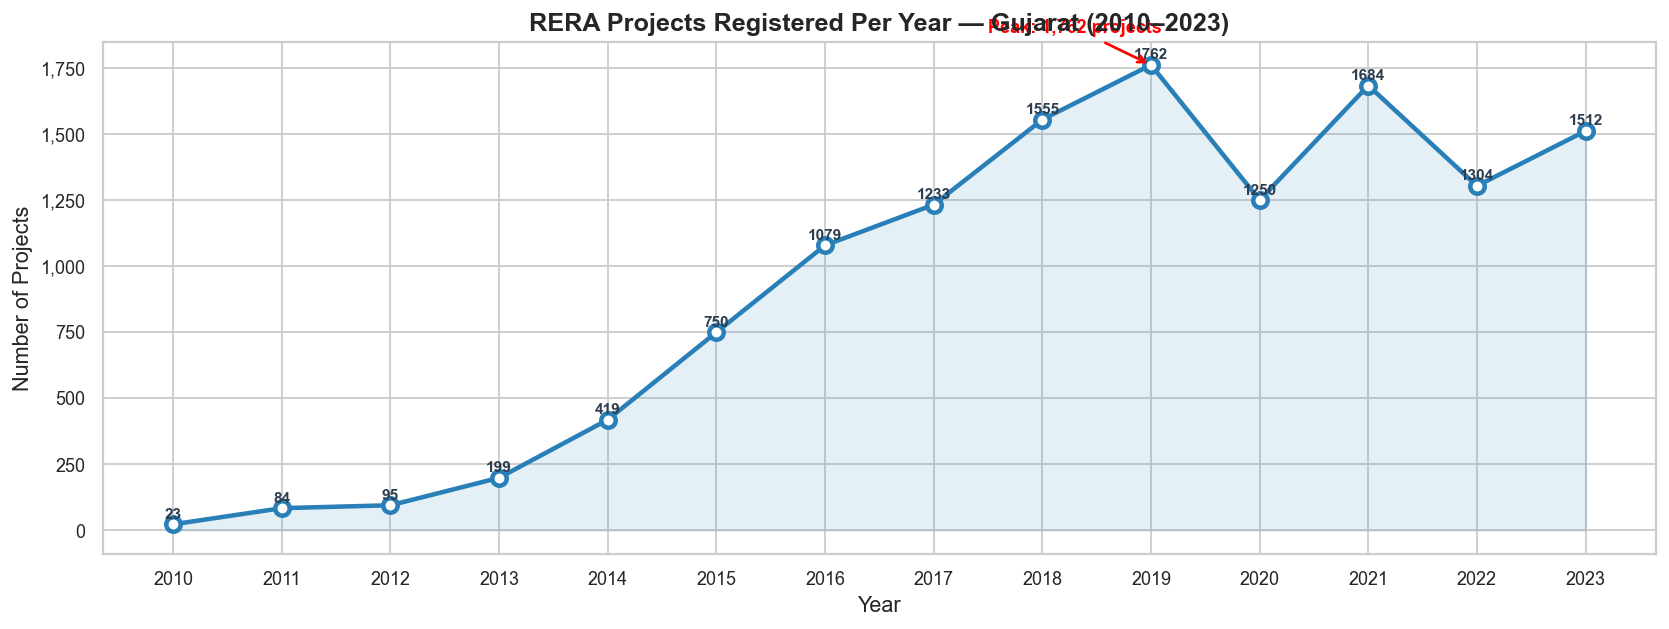

In [5]:
yearly = (
    df.dropna(subset=['startProjectYear'])
      .assign(year=lambda d: d['startProjectYear'].astype(int))
      .query('year >= 2010 and year <= 2023')
      .groupby('year')
      .size()
      .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(yearly['year'], yearly['count'],
        marker='o', linewidth=2.5, markersize=8,
        color='#2980b9', markerfacecolor='white', markeredgewidth=2.5,
        markeredgecolor='#2980b9')

ax.fill_between(
    yearly['year'].to_numpy(dtype=float),
    yearly['count'].to_numpy(dtype=float),
    alpha=0.12,
    color='#2980b9'
)

# Data labels
for _, row in yearly.iterrows():
    ax.text(row['year'], row['count'] + 22, str(int(row['count'])),
            ha='center', fontsize=8.5, color='#2c3e50', fontweight='bold')

# Peak annotation
peak_row = yearly.loc[yearly['count'].idxmax()]
ax.annotate(
    f"Peak: {int(peak_row['count']):,} projects",
    xy=(peak_row['year'], peak_row['count']),
    xytext=(peak_row['year'] - 1.5, peak_row['count'] + 120),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=10, color='red', fontweight='bold'
)

ax.set_title('RERA Projects Registered Per Year — Gujarat (2010–2023)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Projects')
ax.set_xticks(yearly['year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('plot2_projects_per_year')
plt.show()

### Plot 3 — Top 10 Districts by Project Count (Horizontal Bar)

  ✅  Saved → ../reports/plot3_top10_districts.png


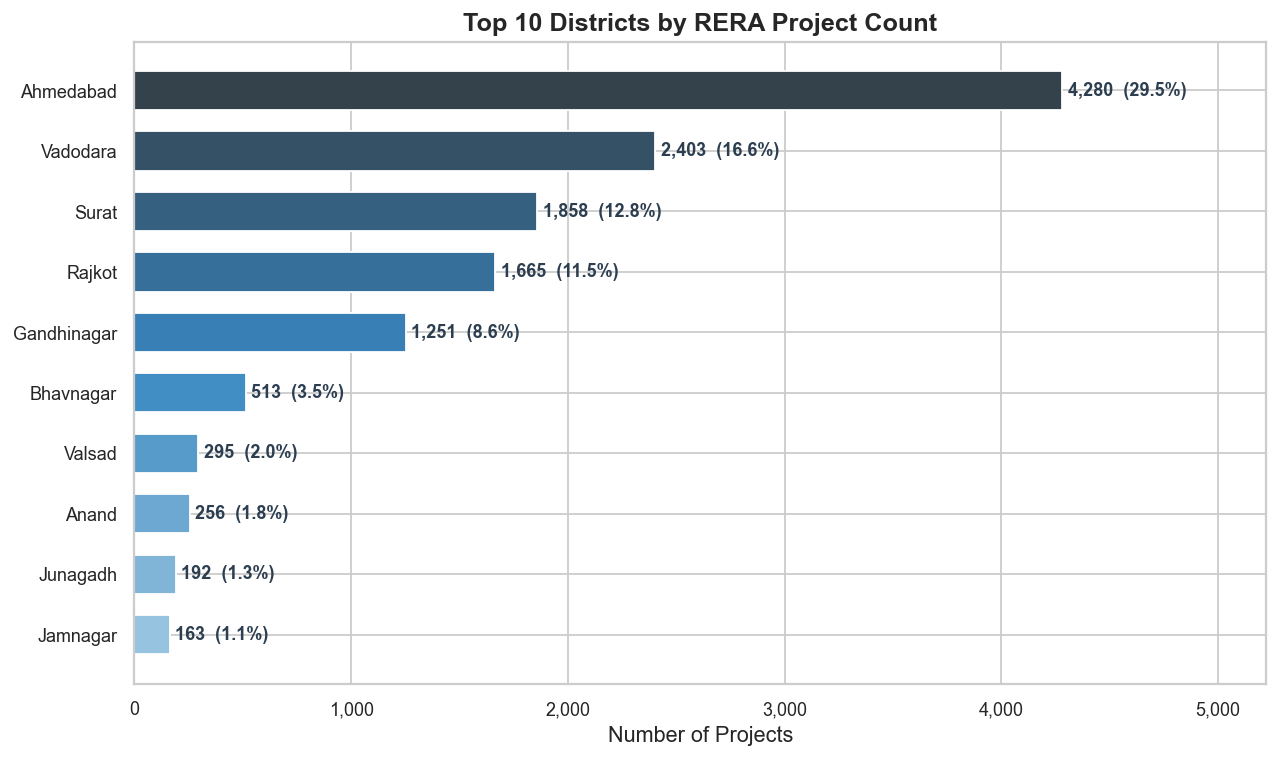

In [6]:
top10 = df['distName'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = sns.color_palette('Blues_d', 10)
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=bar_colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, top10.values[::-1]):
    pct = val / len(df) * 100
    ax.text(
        bar.get_width() + 25,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct:.1f}%)',
        va='center', fontsize=10, color='#2c3e50', fontweight='bold'
    )

ax.set_xlabel('Number of Projects')
ax.set_title('Top 10 Districts by RERA Project Count', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top10.max() * 1.22)
plt.tight_layout()
save_fig('plot3_top10_districts')
plt.show()

### Plot 4 — Distribution of `totalEstimatedCost` (Histogram + Log Scale)

  ✅  Saved → ../reports/plot4_totalEstimatedCost_distribution.png


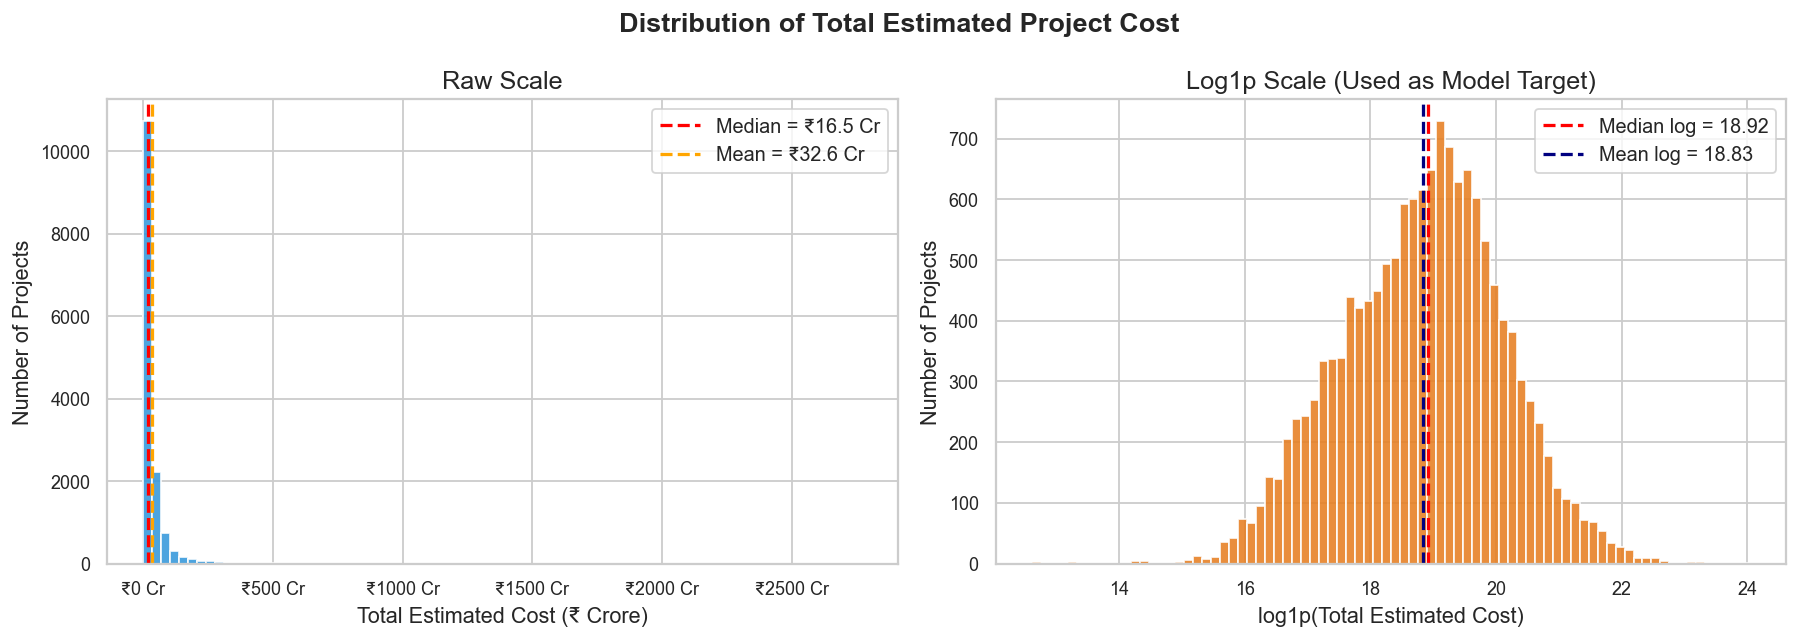

Skewness (raw)  : 12.24
Skewness (log1p): -0.15
99.5th pct      : ₹346.2 Cr  ← outlier threshold


In [7]:
cost = df['totalEstimatedCost'].dropna()
cost = cost[cost > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Total Estimated Project Cost', fontsize=15, fontweight='bold')

# ── Left: Raw scale ──────────────────────────────────────────────────────────
axes[0].hist(cost / 1e7, bins=80, color='#3498db', edgecolor='white', alpha=0.88)
axes[0].axvline(cost.median() / 1e7, color='red', linestyle='--', lw=1.8,
                label=f'Median = ₹{cost.median()/1e7:.1f} Cr')
axes[0].axvline(cost.mean() / 1e7, color='orange', linestyle='--', lw=1.8,
                label=f'Mean = ₹{cost.mean()/1e7:.1f} Cr')
axes[0].set_title('Raw Scale')
axes[0].set_xlabel('Total Estimated Cost (₹ Crore)')
axes[0].set_ylabel('Number of Projects')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f} Cr'))
axes[0].legend()

# ── Right: Log scale ─────────────────────────────────────────────────────────
log_cost = np.log1p(cost)
axes[1].hist(log_cost, bins=80, color='#e67e22', edgecolor='white', alpha=0.88)
axes[1].axvline(log_cost.median(), color='red', linestyle='--', lw=1.8,
                label=f'Median log = {log_cost.median():.2f}')
axes[1].axvline(log_cost.mean(), color='navy', linestyle='--', lw=1.8,
                label=f'Mean log = {log_cost.mean():.2f}')
axes[1].set_title('Log1p Scale (Used as Model Target)')
axes[1].set_xlabel('log1p(Total Estimated Cost)')
axes[1].set_ylabel('Number of Projects')
axes[1].legend()

plt.tight_layout()
save_fig('plot4_totalEstimatedCost_distribution')
plt.show()

print(f'Skewness (raw)  : {cost.skew():.2f}')
print(f'Skewness (log1p): {log_cost.skew():.2f}')
print(f'99.5th pct      : ₹{cost.quantile(0.995)/1e7:.1f} Cr  ← outlier threshold')

### Plot 5 — Distribution of Project Duration (Histogram)

  ✅  Saved → ../reports/plot5_duration_distribution.png


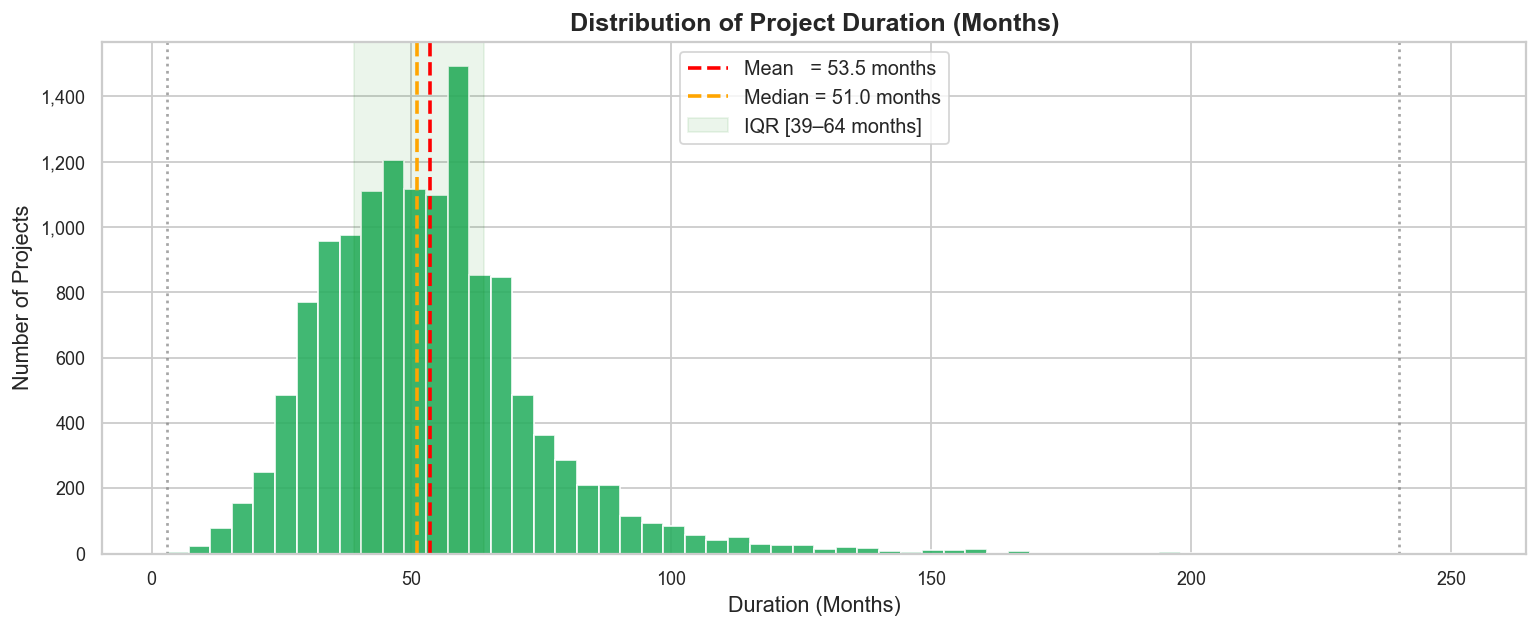

Total rows with duration calculated : 13,632
Negative or zero duration           : 0
> 240 months (extreme outliers)      : 1
Valid [3–240 months]                 : 13,631


In [8]:
# Derive duration (needed for plot — full derivation in Step 1.3 below)
df['duration_months'] = (
    (df['EndProjectYear']  - df['startProjectYear'])  * 12 +
    (df['EndProjectMonth'] - df['startProjectMonth'])
)

dur = df['duration_months'].dropna()
dur_valid = dur[(dur >= 1) & (dur <= 300)]   # exclude clear data errors

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(dur_valid, bins=60, color='#27ae60', edgecolor='white', alpha=0.88)

ax.axvline(dur_valid.mean(),   color='red',    linestyle='--', lw=2,
           label=f'Mean   = {dur_valid.mean():.1f} months')
ax.axvline(dur_valid.median(), color='orange', linestyle='--', lw=2,
           label=f'Median = {dur_valid.median():.1f} months')

# IQR shading
q1, q3 = dur_valid.quantile(0.25), dur_valid.quantile(0.75)
ax.axvspan(q1, q3, alpha=0.08, color='green', label=f'IQR [{q1:.0f}–{q3:.0f} months]')

ax.set_title('Distribution of Project Duration (Months)', fontweight='bold')
ax.set_xlabel('Duration (Months)')
ax.set_ylabel('Number of Projects')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

# Annotation: removal thresholds
ax.axvline(3,   color='grey', linestyle=':', lw=1.5, alpha=0.7, label='Remove <3 months')
ax.axvline(240, color='grey', linestyle=':', lw=1.5, alpha=0.7, label='Remove >240 months')

plt.tight_layout()
save_fig('plot5_duration_distribution')
plt.show()

print(f'Total rows with duration calculated : {dur.notna().sum():,}')
print(f'Negative or zero duration           : {(dur <= 0).sum()}')
print(f'> 240 months (extreme outliers)      : {(dur > 240).sum()}')
print(f'Valid [3–240 months]                 : {((dur >= 3) & (dur <= 240)).sum():,}')

### Plot 6 — Booking Rate Distribution (Histogram)

  ✅  Saved → ../reports/plot6_booking_rate_distribution.png


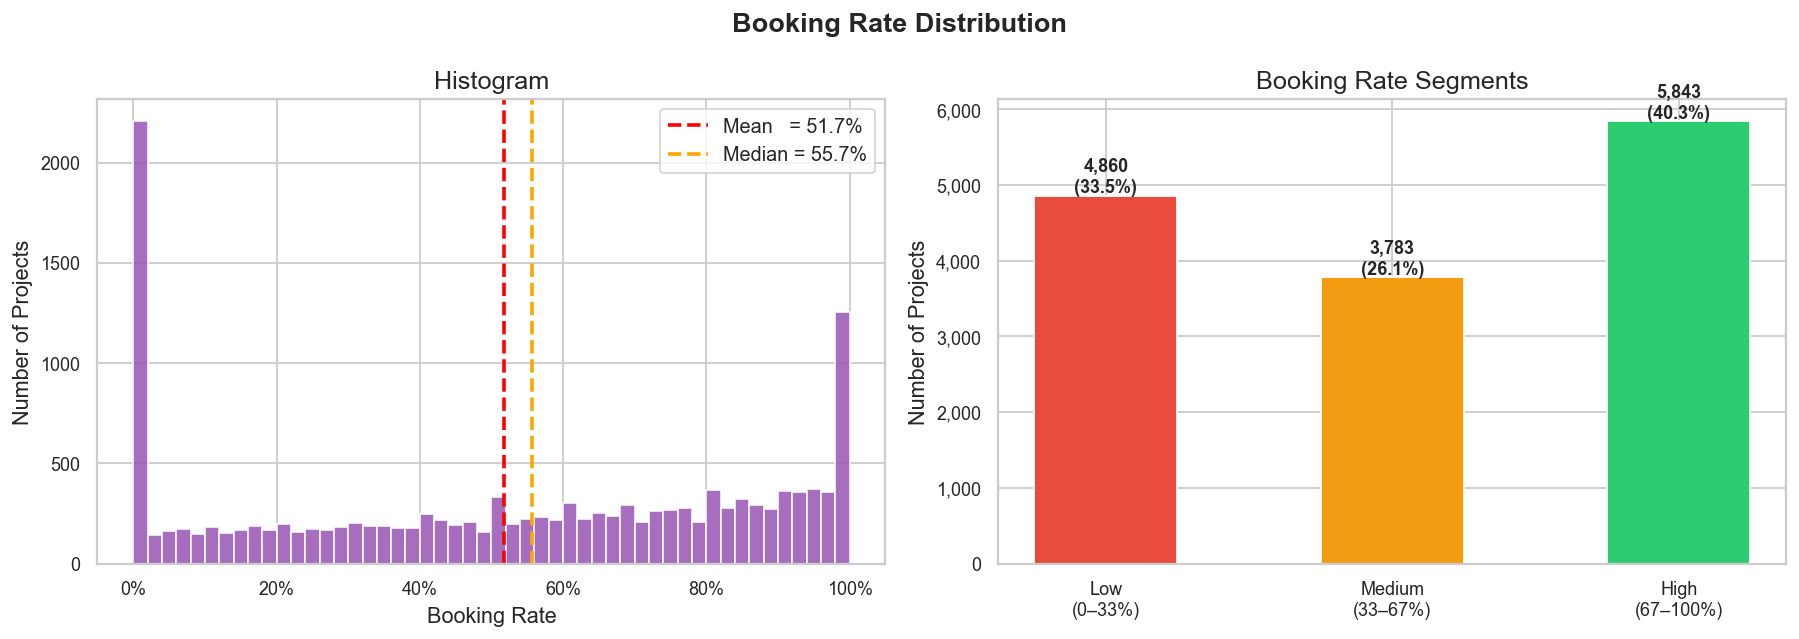

In [9]:
# Derive booking_rate (full derivation in Step 1.3)
df['booking_rate'] = df['bookedUnits'] / df['totalUnits']
df['booking_rate'] = df['booking_rate'].clip(0, 1)

br = df['booking_rate'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Booking Rate Distribution', fontsize=15, fontweight='bold')

# ── Left: Histogram ──────────────────────────────────────────────────────────
axes[0].hist(br, bins=50, color='#9b59b6', edgecolor='white', alpha=0.88)
axes[0].axvline(br.mean(),   color='red',    linestyle='--', lw=2,
                label=f'Mean   = {br.mean():.1%}')
axes[0].axvline(br.median(), color='orange', linestyle='--', lw=2,
                label=f'Median = {br.median():.1%}')
axes[0].set_xlabel('Booking Rate')
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('Histogram')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend()

# ── Right: Segment breakdown ──────────────────────────────────────────────────
labels  = ['Low\n(0–33%)', 'Medium\n(33–67%)', 'High\n(67–100%)']
seg_counts = [
    (br < 0.33).sum(),
    ((br >= 0.33) & (br < 0.67)).sum(),
    (br >= 0.67).sum()
]
bar_c = ['#e74c3c', '#f39c12', '#2ecc71']
bars  = axes[1].bar(labels, seg_counts, color=bar_c, edgecolor='white', width=0.5)

for bar, val in zip(bars, seg_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 40,
                 f'{val:,}\n({val/len(br)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Booking Rate Segments')
axes[1].set_ylabel('Number of Projects')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save_fig('plot6_booking_rate_distribution')
plt.show()

### Plot 7 — `avgCostPerSqFt` by `projectType` (Boxplot — Reveals Outliers)

  ✅  Saved → ../reports/plot7_avgCostPerSqFt_by_projectType.png


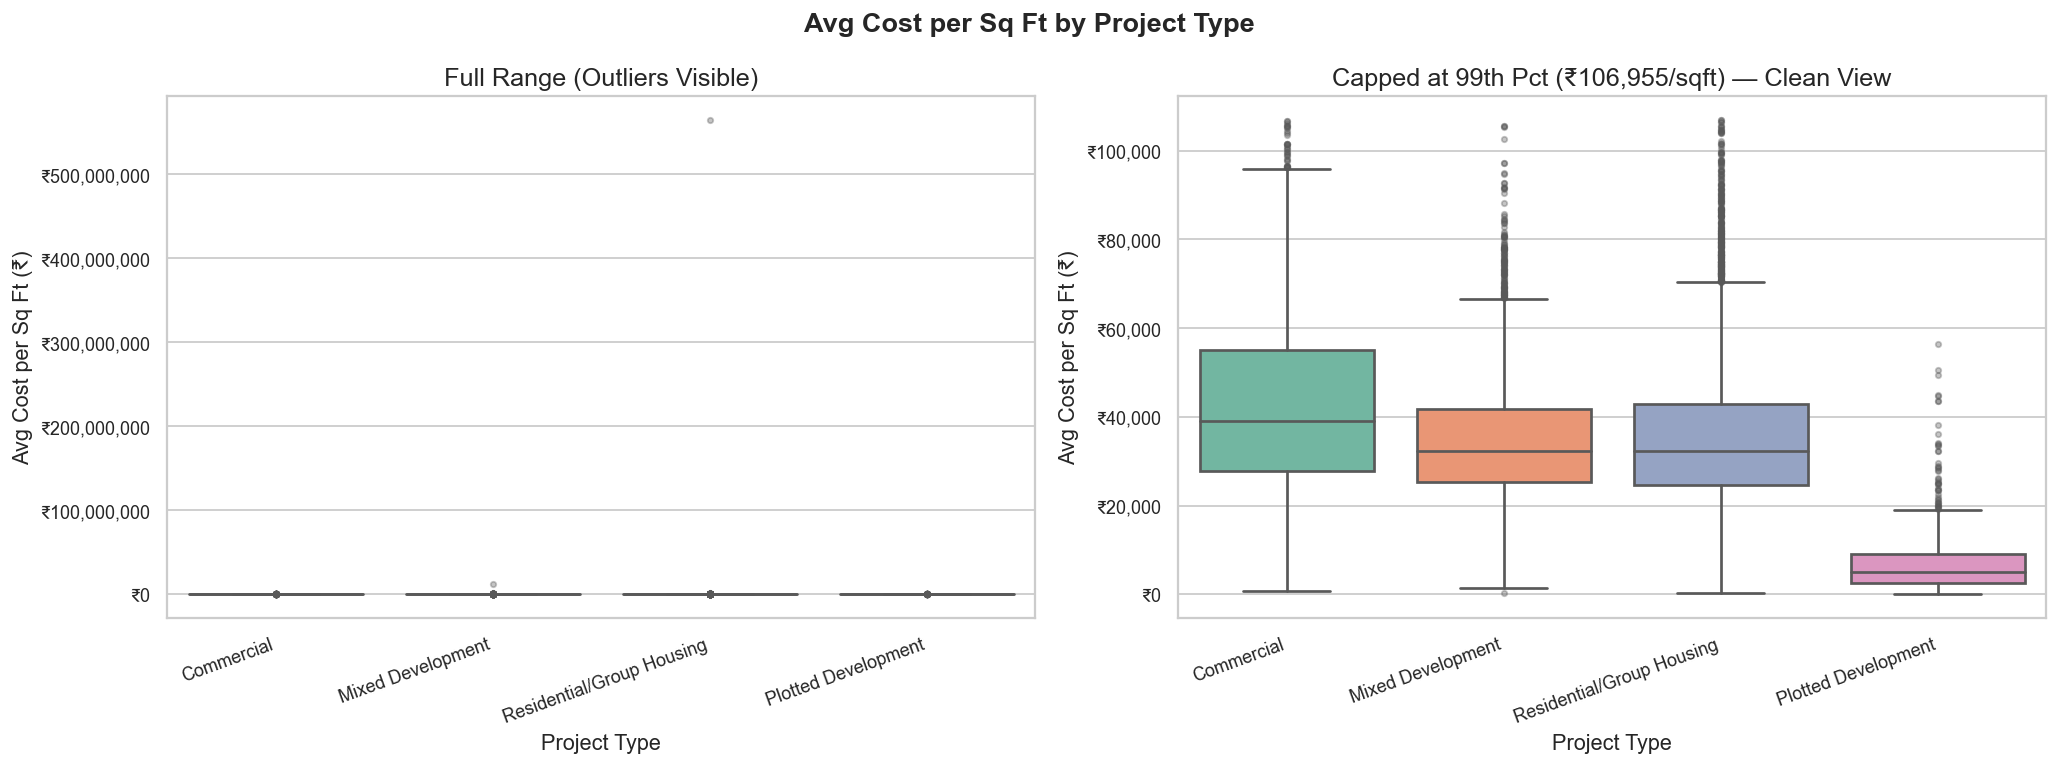

Median avgCostPerSqFt by project type:
projectType
Commercial                   ₹39,583
Mixed Development            ₹32,421
Residential/Group Housing    ₹32,417
Plotted Development           ₹5,099


In [10]:
sqft = df[['avgCostPerSqFt', 'projectType']].dropna()

# Sorted by median for readability
order = sqft.groupby('projectType')['avgCostPerSqFt'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Avg Cost per Sq Ft by Project Type', fontsize=15, fontweight='bold')

# ── Left: Full range (shows outliers) ────────────────────────────────────────
sns.boxplot(
    data=sqft, x='projectType', y='avgCostPerSqFt', order=order,
    palette='Set2', ax=axes[0],
    flierprops=dict(marker='o', markersize=3, alpha=0.35, color='#e74c3c')
)
axes[0].set_title('Full Range (Outliers Visible)')
axes[0].set_xlabel('Project Type')
axes[0].set_ylabel('Avg Cost per Sq Ft (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

# ── Right: Capped at 99th pct (clean view) ────────────────────────────────────
cap = sqft['avgCostPerSqFt'].quantile(0.99)
sqft_clean = sqft[sqft['avgCostPerSqFt'] <= cap]

sns.boxplot(
    data=sqft_clean, x='projectType', y='avgCostPerSqFt', order=order,
    palette='Set2', ax=axes[1],
    flierprops=dict(marker='o', markersize=3, alpha=0.35, color='#e74c3c')
)
axes[1].set_title(f'Capped at 99th Pct (₹{cap:,.0f}/sqft) — Clean View')
axes[1].set_xlabel('Project Type')
axes[1].set_ylabel('Avg Cost per Sq Ft (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
save_fig('plot7_avgCostPerSqFt_by_projectType')
plt.show()

print('Median avgCostPerSqFt by project type:')
print(sqft.groupby('projectType')['avgCostPerSqFt'].median().sort_values(ascending=False)
         .apply(lambda x: f'₹{x:,.0f}').to_string())

### Plot 8 — Correlation Heatmap (All Numeric Columns)

  ✅  Saved → ../reports/plot8_correlation_heatmap.png


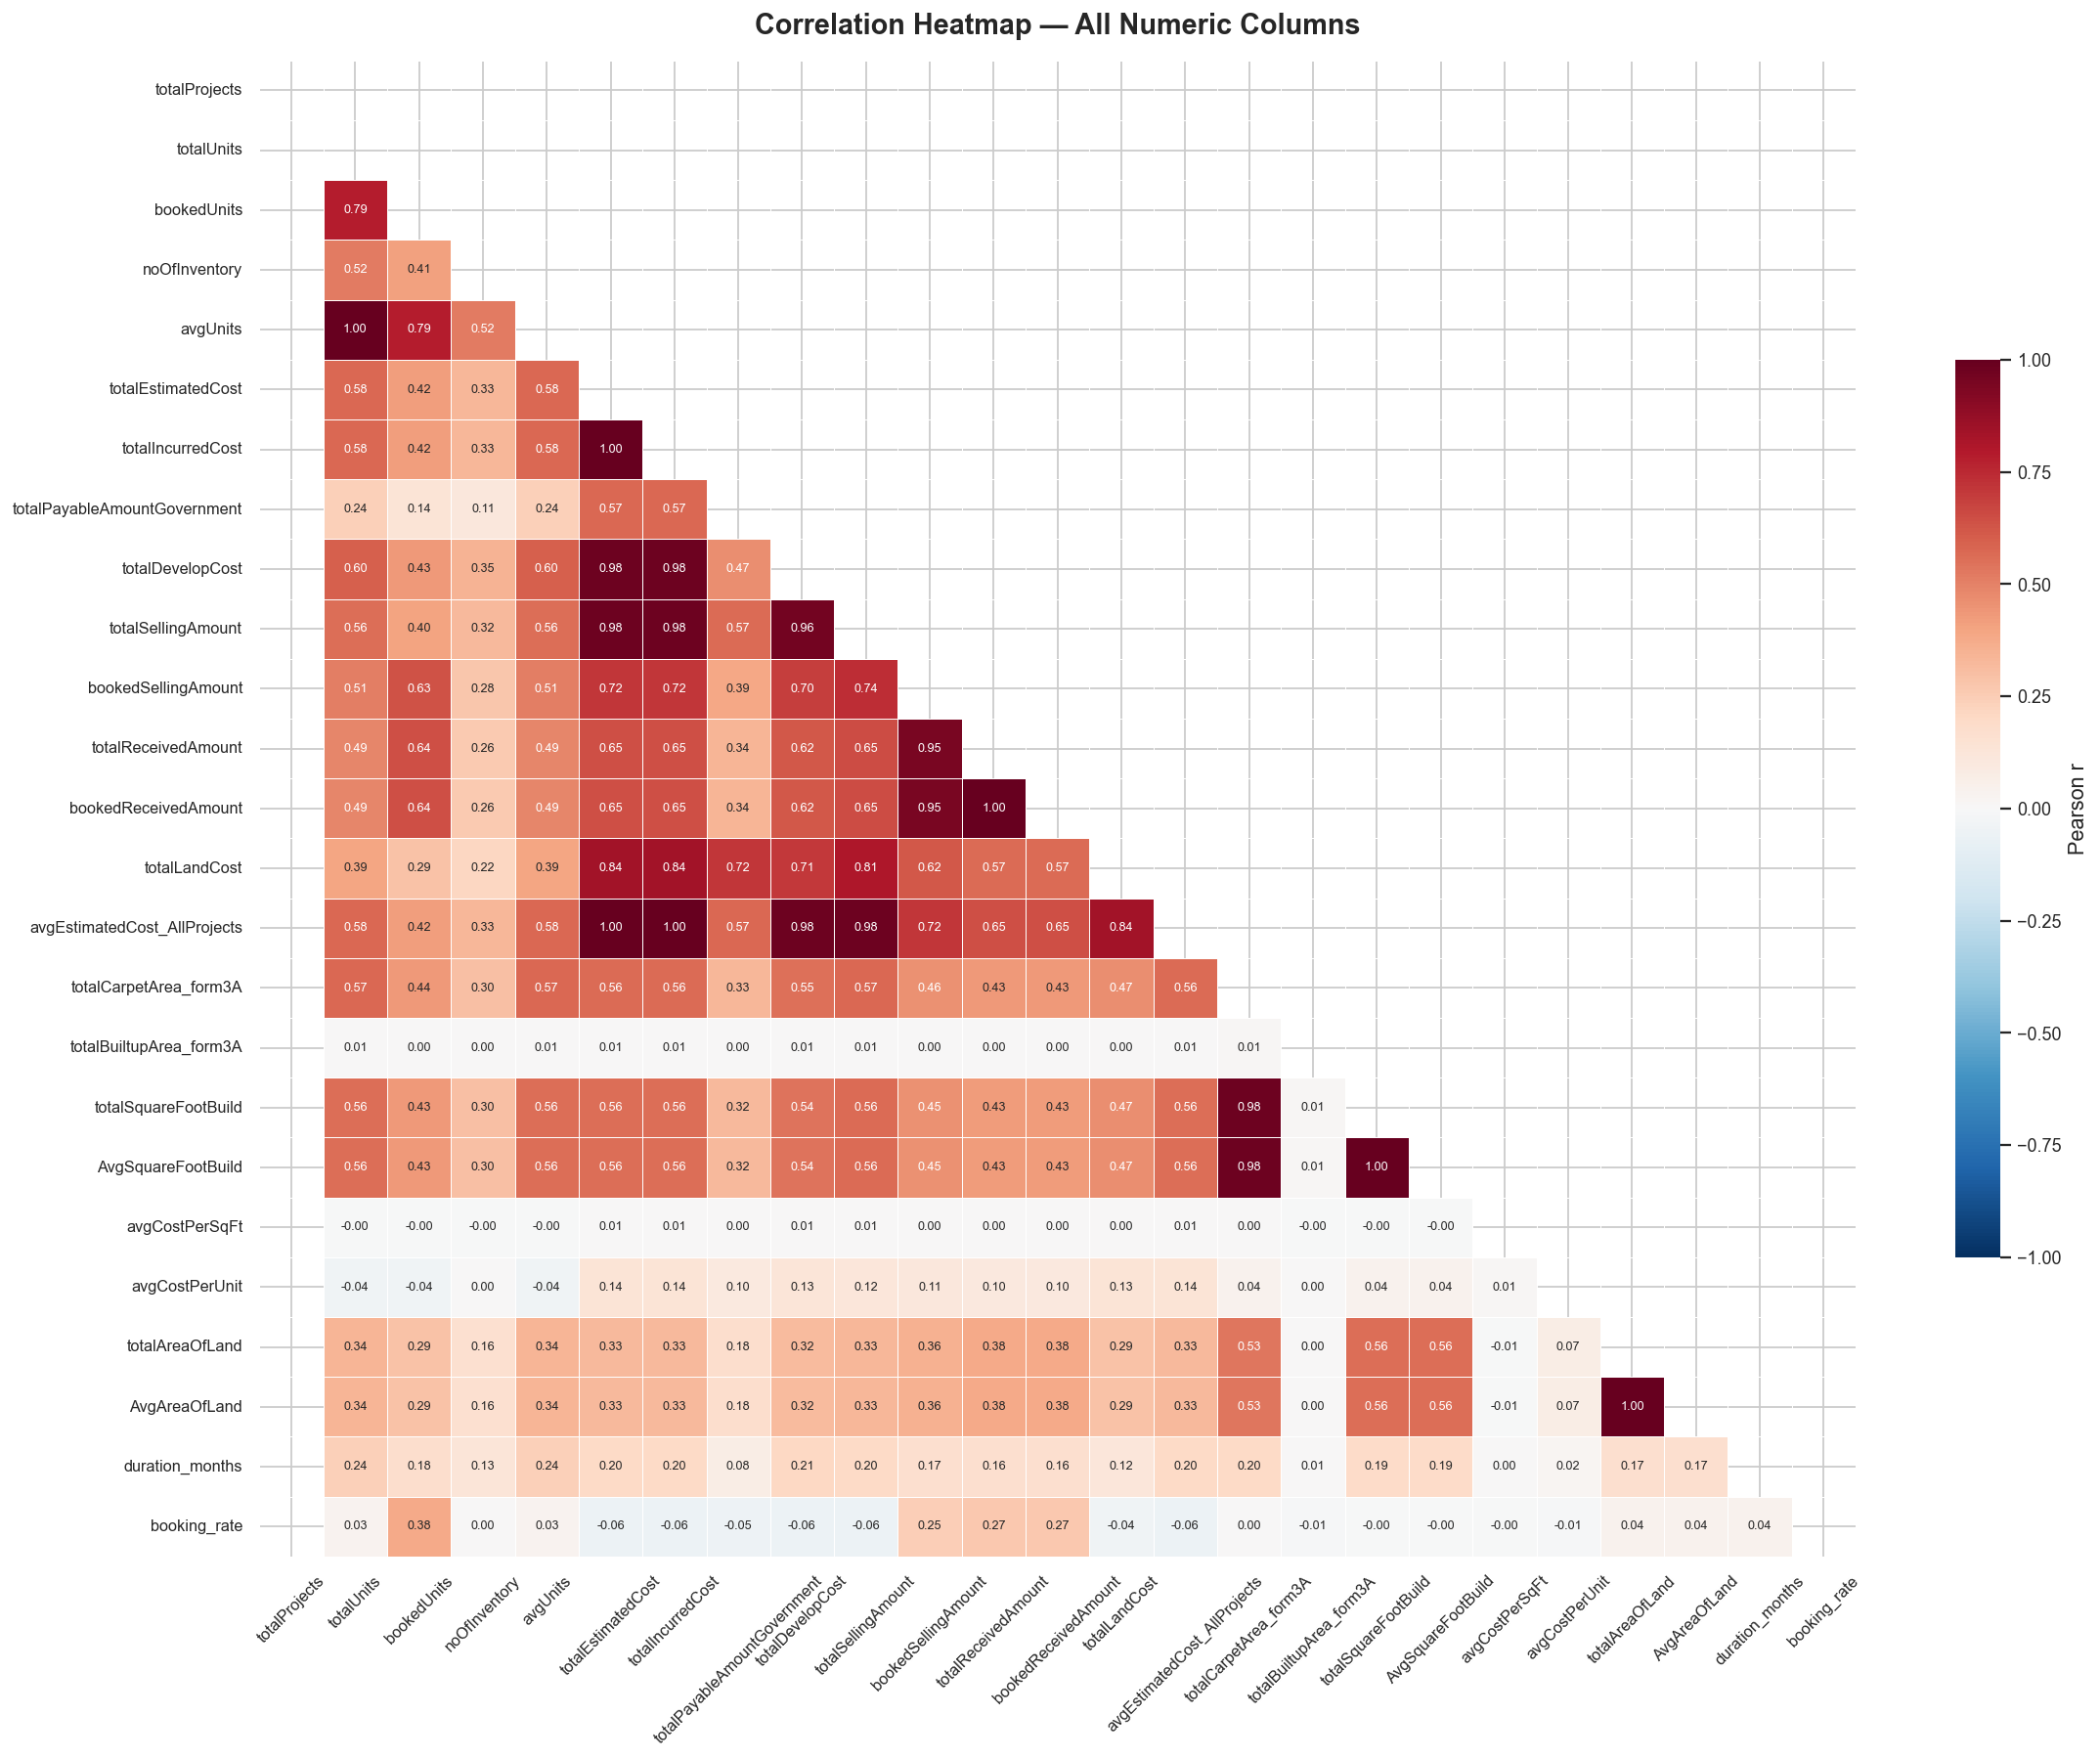

In [11]:
# All numeric columns (exclude ID and date-part columns that are just integers)
EXCLUDE = ['projectRegId', 'pinCode', 'tpo_code',
           'startProjectYear', 'startProjectMonth',
           'EndProjectYear',   'EndProjectMonth']

num_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws=dict(shrink=0.6, label='Pearson r'),
    ax=ax
)

ax.set_title('Correlation Heatmap — All Numeric Columns',
             fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
save_fig('plot8_correlation_heatmap')
plt.show()

In [12]:
# Top 10 strongest correlations (excluding self-correlations)
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'r']
print('Top 10 Strongest Correlations:')
print(
    corr_pairs.assign(abs_r=corr_pairs['r'].abs())
              .sort_values('abs_r', ascending=False)
              .head(10)[['Feature A', 'Feature B', 'r']]
              .to_string(index=False)
)

Top 10 Strongest Correlations:
                   Feature A              Feature B        r
          AvgSquareFootBuild   totalSquareFootBuild 1.000000
        bookedReceivedAmount    totalReceivedAmount 1.000000
                    avgUnits             totalUnits 1.000000
avgEstimatedCost_AllProjects      totalIncurredCost 1.000000
avgEstimatedCost_AllProjects     totalEstimatedCost 1.000000
               AvgAreaOfLand        totalAreaOfLand 1.000000
           totalIncurredCost     totalEstimatedCost 1.000000
          AvgSquareFootBuild totalCarpetArea_form3A 0.982477
        totalSquareFootBuild totalCarpetArea_form3A 0.982477
          totalSellingAmount     totalEstimatedCost 0.980161


---
## Step 1.3 — Key EDA Findings to Document

In [13]:
# ── Project duration ──────────────────────────────────────────────────────────
df['duration_months'] = (df['EndProjectYear'] - df['startProjectYear']) * 12 \
                       + (df['EndProjectMonth'] - df['startProjectMonth'])

# ── Booking rate ──────────────────────────────────────────────────────────────
df['booking_rate'] = df['bookedUnits'] / df['totalUnits']

# ── Profit margin indicator ───────────────────────────────────────────────────
df['margin'] = (df['totalSellingAmount'] - df['totalDevelopCost']) \
               / df['totalSellingAmount']

print("Avg duration:",     df['duration_months'].mean(), "months")
print("Avg booking rate:", df['booking_rate'].mean())
print("Avg margin:",       df['margin'].mean())

Avg duration: 53.49119718309859 months
Avg booking rate: 0.5171497417454246
Avg margin: -inf


In [14]:
# ── Extended findings ─────────────────────────────────────────────────────────
print('=' * 60)
print('  DURATION')
print(f'  Mean   : {df["duration_months"].mean():.1f} months')
print(f'  Median : {df["duration_months"].median():.1f} months')
print(f'  Std    : {df["duration_months"].std():.1f} months')
print(f'  Range  : {df["duration_months"].min():.0f} to {df["duration_months"].max():.0f} months')
print()
print('  BOOKING RATE')
print(f'  Mean   : {df["booking_rate"].mean():.1%}')
print(f'  Median : {df["booking_rate"].median():.1%}')
print(f'  > 100% (data errors) : {(df["booking_rate"] > 1).sum()}')
print()
print('  PROFIT MARGIN')
print(f'  Mean   : {df["margin"].mean():.1%}')
print(f'  Median : {df["margin"].median():.1%}')
print(f'  Negative margins : {(df["margin"] < 0).sum()}')
print()
print('  COST')
print(f'  Mean   : ₹{df["totalEstimatedCost"].mean()/1e7:.2f} Cr')
print(f'  Median : ₹{df["totalEstimatedCost"].median()/1e7:.2f} Cr')
print(f'  Total  : ₹{df["totalEstimatedCost"].sum()/1e9:.1f} Billion')
print('=' * 60)

  DURATION
  Mean   : 53.5 months
  Median : 51.0 months
  Std    : 21.2 months
  Range  : 3 to 252 months

  BOOKING RATE
  Mean   : 51.7%
  Median : 55.7%
  > 100% (data errors) : 0

  PROFIT MARGIN
  Mean   : -inf%
  Median : 33.4%
  Negative margins : 449

  COST
  Mean   : ₹32.59 Cr
  Median : ₹16.47 Cr
  Total  : ₹4727.8 Billion


## Plots Saved — Summary

In [15]:
saved = sorted([f for f in os.listdir('../reports') if f.endswith('.png')])
print(f'All EDA plots saved to ../reports/  ({len(saved)} files)\n')
for f in saved:
    print(f'  📊  {f}')

print()
print('✅  Phase 1 — EDA Complete')
print('➡   Next: notebooks/02_cleaning.ipynb')

All EDA plots saved to ../reports/  (8 files)

  📊  plot1_projectType_distribution.png
  📊  plot2_projects_per_year.png
  📊  plot3_top10_districts.png
  📊  plot4_totalEstimatedCost_distribution.png
  📊  plot5_duration_distribution.png
  📊  plot6_booking_rate_distribution.png
  📊  plot7_avgCostPerSqFt_by_projectType.png
  📊  plot8_correlation_heatmap.png

✅  Phase 1 — EDA Complete
➡   Next: notebooks/02_cleaning.ipynb


---
## EDA Findings → Phase 2 Actions

| # | Finding | Phase 2 Action |
|---|---------|---------------|
| 1 | `pinCode`, `tPNo`, `totalAreaOfLand`, `AvgAreaOfLand`, `architect_name`, `eng_name` — >30% null | **Drop columns** |
| 2 | `distName`, `startDate`, `completionDate` — ~6% null | **Drop rows** |
| 3 | `noOfInventory` — 17% null | **Median impute** per `projectType` |
| 4 | `totalEstimatedCost` is heavily right-skewed | **log1p-transform** as model target |
| 5 | `duration_months` has negative values (data errors) | **Remove <3 and >240 months** |
| 6 | `booking_rate` > 1.0 (impossible values) | **Clip to [0, 1]** |
| 7 | `avgCostPerSqFt` extreme outliers at 99th pct | **Cap at 99th percentile** |
| 8 | `totalEstimatedCost` outliers beyond 99.5th pct | **Remove** top 0.5% |
| 9 | Strong multi-collinearity: cost columns correlated | **Keep only engineered features** in Phase 3 |